<a href="https://colab.research.google.com/github/DimiGretsistas/Automated-Customers-Reviews-Project/blob/main/notebooks/04_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Summarization

**Goals**
- Use a small generative model to create short recommendation articles from clustered product reviews.
- This notebook recreates the clustered sample directly, so it does not depend on the clustering notebook.

In [52]:
import pandas as pd

#load cleaned dataset from Colab
df = pd.read_csv(
    "/content/clean_reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

# inspect data
df.head()

,name,reviews.rating,reviews.text,sentiment,clean_review
0,AmazonBasics AAA Performance Alkaline Batterie...,3,I order 3 of them and one of the item is bad q...,neutral,i order 3 of them and one of the item is bad q...
1,AmazonBasics AAA Performance Alkaline Batterie...,4,Bulk is always the less expensive way to go fo...,positive,bulk is always the less expensive way to go fo...
2,AmazonBasics AAA Performance Alkaline Batterie...,5,Well they are not Duracell but for the price i...,positive,well they are not duracell but for the price i...
3,AmazonBasics AAA Performance Alkaline Batterie...,5,Seem to work as well as name brand batteries a...,positive,seem to work as well as name brand batteries a...
4,AmazonBasics AAA Performance Alkaline Batterie...,5,These batteries are very long lasting the pric...,positive,these batteries are very long lasting the pric...


## Create Sample for Summarization
- Using a smaller sample to keep the notebook fast.

In [53]:
#use a smaller sample for fast processing
sample_df = df.sample(n=1000, random_state=42).copy()

#check sample size
sample_df.shape

(1000, 5)

## Create Embeddings and Clusters
- Using a pretrained sentence transformer and KMeans to recreate product clusters.

In [54]:
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

#prepare review texts
texts = sample_df["clean_review"].tolist()

#load embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

#create embeddings
embeddings = embedding_model.encode(texts, show_progress_bar=True)

#create 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

#assign clusters
sample_df["cluster"] = kmeans.fit_predict(embeddings)

sample_df[["name", "clean_review", "cluster"]].head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

,name,clean_review,cluster
45193,Amazon Kindle Paperwhite - eBook reader - 4 GB...,i bought this for an employee of mine she love...,1
22309,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",great starter to teach young children how to p...,4
34885,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",just what my kids needed for a road trip easy ...,3
16409,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",nicer than my old fire better screen area to view,3
23893,"Kindle E-reader - White, 6 Glare-Free Touchscr...",my fianc e really enjoyes it i would definitel...,3


## Inspect Clustered Sample
- Checking available clusters and products in the sampled data.

In [55]:
#check sample dataset size
print(sample_df.shape)

#check available clusters
print(sample_df["cluster"].value_counts())

#inspect clustered sample
sample_df[["name", "reviews.rating", "sentiment", "cluster"]].head()

(1000, 6)
cluster
0    277
3    266
1    187
2    140
4    130
Name: count, dtype: int64


,name,reviews.rating,sentiment,cluster
45193,Amazon Kindle Paperwhite - eBook reader - 4 GB...,5,positive,1
22309,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",5,positive,4
34885,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5,positive,3
16409,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5,positive,3
23893,"Kindle E-reader - White, 6 Glare-Free Touchscr...",4,positive,3


## Prepare Product Insights
- Extracting top products, worst product, and complaints per cluster.

In [56]:
def prepare_cluster_insights(cluster_df):
    #calculate average rating per product
    product_stats = cluster_df.groupby("name").agg(
        avg_rating=("reviews.rating", "mean"),
        review_count=("reviews.rating", "count")
    ).reset_index()

    #keep products with at least 3 reviews
    product_stats = product_stats[product_stats["review_count"] >= 3]

    #top 3 products
    top_products = product_stats.sort_values(
        by="avg_rating",
        ascending=False
    ).head(3)

    #worst product
    worst_product = product_stats.sort_values(
        by="avg_rating",
        ascending=True
    ).head(1)

    #complaints (negative reviews)
    complaints = cluster_df[
        cluster_df["sentiment"] == "negative"
    ]["clean_review"].head(5).tolist()

    return top_products, worst_product, complaints

In [57]:
#test for one cluster
cluster_df = sample_df[sample_df["cluster"] == 0]

top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

print("Top products:")
print(top_products)

print("\nWorst product:")
print(worst_product)

print("\nComplaints:")
print(complaints)

Top products:
                                                 name  avg_rating  \
5   All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...    5.000000   
6   All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...    4.791667   
28  Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...    4.750000   

    review_count  
5             13  
6             24  
28            16  

Worst product:
                                                name  avg_rating  review_count
8  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...    3.666667             3

Complaints:
['the headphone jack restarts the tablet when you plug the headphone cord into it that is why i am giving the product only 2 stars otherwise the screen is great', 'i found this devices battery very poor and also didn t like this device can t support screen share capabilities with my amazon fire tv or smart tv s', 'super slow not of decent quality i would not buy another memory on it is lacking for 8 gig i will not recommend it to anyone', 'ne

##Clean Product Names
- Fixing formatting issues in product names.

In [58]:
#clean messy product names (remove commas, line breaks)
sample_df["name"] = sample_df["name"].str.replace(r"[\r\n,]+", " ", regex=True).str.strip()

##-----------------------------------------------------------
## Inspect Clustered Sample
- Checking available clusters and products in the sampled data.

In [93]:
cluster_names = {
    0: "Tablets / Multimedia Devices",
    1: "Kindle / Reading Devices",
    2: "Batteries / General Products",
    3: "Smart Home / Alexa Devices",
    4: "Gifts / Casual Usage"
}

In [80]:
#check sample dataset size
print(sample_df.shape)

#check available clusters
print(sample_df["cluster"].value_counts())

#inspect clustered sample
sample_df[["name", "reviews.rating", "sentiment", "cluster"]].head()


(1000, 6)
cluster
0    277
3    266
1    187
2    140
4    130
Name: count, dtype: int64


,name,reviews.rating,sentiment,cluster
45193,Amazon Kindle Paperwhite - eBook reader - 4 GB...,5,positive,1
22309,Fire Kids Edition Tablet 7 Display Wi-Fi 16...,5,positive,4
34885,Fire Tablet 7 Display Wi-Fi 8 GB - Includes...,5,positive,3
16409,All-New Fire HD 8 Tablet 8 HD Display Wi-Fi ...,5,positive,3
23893,Kindle E-reader - White 6 Glare-Free Touchscr...,4,positive,3


##Load Generator Model
- Using a small generative model to create recommendation text.

In [81]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    max_new_tokens=300,
    device_map="auto"
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

##Generate Recommendation Article
- Create a short blog-style summary for one cluster.

In [82]:
#select cluster
cluster_id = 0

cluster_df = sample_df[sample_df["cluster"] == cluster_id]

top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

prompt = f"""
Write a short product recommendation article.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Complaints:
{complaints}

Include:
- Top 3 products
- Differences
- Complaints
- Worst product warning
"""

result = generator(prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Write a short product recommendation article.

Top products:
                                                                                   name  avg_rating  review_count
  All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Black    5.000000            13
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Magenta    4.791667            24
                  Fire Tablet  7 Display  Wi-Fi  16 GB - Includes Special Offers  Black    4.750000            16

Worst product:
                                                                                name  avg_rating  review_count
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  32 GB - Includes Special Offers  Blue    3.666667             3

Complaints:
['the headphone jack restarts the tablet when you plug the headphone cord into it that is why i am giving the product only 2 stars otherwise the screen is great', 'i found this devices battery very poor and also didn t like this de

In [85]:
#Prompt Variation 2

prompt = f"""
You are a tech reviewer.

Write a short, clear product recommendation article based ONLY on the data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- Be concise and factual
- Do NOT invent products
- Do NOT mention brands not listed
- Focus on differences and real issues

Structure:
1. Introduction
2. Top products comparison
3. Key complaints
4. Worst product warning
5. Final recommendation
"""

result = generator(prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech reviewer.

Write a short, clear product recommendation article based ONLY on the data below.

Top products:
                                                                                   name  avg_rating  review_count
  All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Black    5.000000            13
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Magenta    4.791667            24
                  Fire Tablet  7 Display  Wi-Fi  16 GB - Includes Special Offers  Black    4.750000            16

Worst product:
                                                                                name  avg_rating  review_count
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  32 GB - Includes Special Offers  Blue    3.666667             3

Customer complaints:
['the headphone jack restarts the tablet when you plug the headphone cord into it that is why i am giving the product only 2 stars otherwise the screen is great

In [84]:
#Prompt variation 3

prompt = f"""
You are a tech reviewer.

Write a short, structured product recommendation article based ONLY on the data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- Only use the information provided
- Do NOT invent features or products
- Be concise and factual

Structure:
1. Introduction
2. Top products comparison (bullet points)
3. Key complaints (bullet points)
4. Worst product warning
5. Final recommendation
"""

result = generator(prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech reviewer.

Write a short, structured product recommendation article based ONLY on the data below.

Top products:
                                                                                   name  avg_rating  review_count
  All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Black    5.000000            13
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Magenta    4.791667            24
                  Fire Tablet  7 Display  Wi-Fi  16 GB - Includes Special Offers  Black    4.750000            16

Worst product:
                                                                                name  avg_rating  review_count
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  32 GB - Includes Special Offers  Blue    3.666667             3

Customer complaints:
['the headphone jack restarts the tablet when you plug the headphone cord into it that is why i am giving the product only 2 stars otherwise the screen is 

## N-Shot Prompting

- Instead of fine-tuning the generator today, we improved the model output using n-shot prompting.  
- This means we provide the model with examples of the expected output format before asking it to generate a new product recommendation article.

In [86]:
n_shot_prompt = f"""
You are a tech product reviewer.

Example:

Input:
Top products: Product A, Product B, Product C
Complaints: battery issues, slow setup
Worst product: Product D

Output:
Product A performs best overall based on customer ratings.
Product B offers a good balance between features and usability.
Product C is suitable for basic use cases.

Common complaints include battery problems and setup difficulties.
Product D should be avoided due to negative customer feedback.

---

Now use ONLY the real data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- ONLY use the products listed above
- DO NOT reuse example names
- Be concise and factual
- Mention top products, complaints, worst product, and recommendation
"""

result = generator(n_shot_prompt)

print(result[0]["generated_text"])

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech product reviewer.

Example:

Input:
Top products: Product A, Product B, Product C
Complaints: battery issues, slow setup
Worst product: Product D

Output:
Product A performs best overall based on customer ratings.
Product B offers a good balance between features and usability.
Product C is suitable for basic use cases.

Common complaints include battery problems and setup difficulties.
Product D should be avoided due to negative customer feedback.

---

Now use ONLY the real data below.

Top products:
                                                                                   name  avg_rating  review_count
  All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Black    5.000000            13
All-New Fire HD 8 Tablet  8 HD Display  Wi-Fi  16 GB - Includes Special Offers  Magenta    4.791667            24
                  Fire Tablet  7 Display  Wi-Fi  16 GB - Includes Special Offers  Black    4.750000            16

Worst product:
     

##N-Shot Prompting Insights (1-Shot only)

- N-shot prompting improved the structure of the generated recommendation article.
- The model followed the example format and used the real product data more effectively.
- Some minor inaccuracies can still appear, showing that generated outputs require validation.
- This confirms that prompt design strongly affects summarization quality.

##2-Shot Prompting

- Using two examples to improve output structure, consistency, and factual generation quality.

In [92]:
#using one cluster as test example
cluster_id = 4

#selecting cluster reviews
cluster_df = sample_df[sample_df["cluster"] == cluster_id]

#extracting insights
top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

#2-shot prompt
two_shot_prompt = f"""
You are a tech product reviewer.

Example 1:

Input:
Top products: Kindle Paperwhite, Fire HD Tablet, Echo Dot
Complaints: battery issues, slow setup
Worst product: Echo Plus

Output:
The Kindle Paperwhite performs very well for reading and portability.
The Fire HD Tablet is a good multimedia device for casual users.
The Echo Dot is useful for smart home interaction and voice control.

Common complaints include battery problems and setup difficulties.
The Echo Plus received weaker feedback and may not be the best choice for users seeking reliability.

---

Example 2:

Input:
Top products: Fire TV Stick, Amazon Fire Tablet, Echo Show
Complaints: connectivity issues, app compatibility
Worst product: Fire Kids Tablet

Output:
The Fire TV Stick is a strong option for streaming and entertainment.
The Amazon Fire Tablet offers good value for multimedia usage.
The Echo Show provides useful smart home and display functionality.

Customers reported issues related to connectivity and app compatibility.
The Fire Kids Tablet received the weakest feedback and may not satisfy all users.

---

Now use ONLY the real data below.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Customer complaints:
{complaints}

Rules:
- ONLY use the products listed above
- DO NOT invent products or features
- DO NOT reuse example product names
- Be concise and factual
- Mention top products, complaints, worst product, and recommendation
- Use short and clear sentences
- End the article after the final recommendation
- Do not continue writing extra explanations
"""

# generate article
result = generator(
    two_shot_prompt,
    max_new_tokens=250
)

# print result
print(result[0]["generated_text"])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are a tech product reviewer.

Example 1:

Input:
Top products: Kindle Paperwhite, Fire HD Tablet, Echo Dot
Complaints: battery issues, slow setup
Worst product: Echo Plus

Output:
The Kindle Paperwhite performs very well for reading and portability.
The Fire HD Tablet is a good multimedia device for casual users.
The Echo Dot is useful for smart home interaction and voice control.

Common complaints include battery problems and setup difficulties.
The Echo Plus received weaker feedback and may not be the best choice for users seeking reliability.

---

Example 2:

Input:
Top products: Fire TV Stick, Amazon Fire Tablet, Echo Show
Complaints: connectivity issues, app compatibility
Worst product: Fire Kids Tablet

Output:
The Fire TV Stick is a strong option for streaming and entertainment.
The Amazon Fire Tablet offers good value for multimedia usage.
The Echo Show provides useful smart home and display functionality.

Customers reported issues related to connectivity and app compat

##N-Shot Prompting Insights (2-Shots)

- Using two examples improved the structure and consistency of the generated recommendation articles.
- The model followed the requested format more reliably compared to the previous 1-shot version.
- Hallucinations and irrelevant product references were reduced.
- The generated summaries became more focused on the real product data and customer complaints.
- Prompt

##Fine-Tuning Dataset Preparation

- Prepare training examples for generator fine-tuning.

- The model will learn to generate recommendation articles from structured product insights.

In [65]:
fine_tune_data = []

#create small training dataset from clusters
for cluster_id in sample_df["cluster"].unique():

    cluster_df = sample_df[sample_df["cluster"] == cluster_id]

    top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

    #input text
    input_text = f"""
    Top products:
    {top_products.to_string(index=False)}

    Worst product:
    {worst_product.to_string(index=False)}

    Complaints:
    {complaints}
    """

    #target output
    target_text = f"""
    Recommended products include:
    {", ".join(top_products['name'].tolist())}.

    Common complaints include:
    {", ".join(complaints[:2])}

    Product to avoid:
    {worst_product['name'].iloc[0]}.
    """

    fine_tune_data.append({
        "input_text": input_text,
        "target_text": target_text
    })

#convert to dataframe
fine_tune_df = pd.DataFrame(fine_tune_data)

fine_tune_df.head()

,input_text,target_text
0,\n Top products:\n ...,\n Recommended products include:\n Fire ...
1,\n Top products:\n ...,\n Recommended products include:\n All-N...
2,\n Top products:\n ...,\n Recommended products include:\n Amazo...
3,\n Top products:\n ...,\n Recommended products include:\n Amazo...
4,\n Top products:\n ...,\n Recommended products include:\n All-N...


##Load Fine-Tuning Model

- Loading a small text-to-text model for generator fine-tuning.
- Using FLAN-T5 Small because it is lightweight and suitable for fast experiments in Colab.

In [66]:
!pip install datasets evaluate rouge_score sacrebleu -q

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

#convert dataframe to Hugging Face Dataset
train_dataset = Dataset.from_pandas(fine_tune_df)

#load tokenizer and model
model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
ft_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


##Tokenize Fine-Tuning Data

Converting input and target texts into token IDs so the model can learn from them.

In [67]:
def tokenize_function(example):
    #tokenize input text
    model_inputs = tokenizer(
        example["input_text"],
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    #tokenize target text
    labels = tokenizer(
        example["target_text"],
        max_length=256,
        truncation=True,
        padding="max_length"
    )

    #add labels for training
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


tokenized_dataset = train_dataset.map(tokenize_function)

tokenized_dataset

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Dataset({
    features: ['input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 5
})

##Fine-Tune Generator Model

- Training the FLAN-T5 model on the generated recommendation examples.

In [68]:
from transformers import TrainingArguments, Trainer

#training configuration
training_args = TrainingArguments(
    output_dir="/content/flan_t5_finetuned",
    num_train_epochs=20,
    per_device_train_batch_size=2,
    learning_rate=5e-5,
    logging_steps=1,
    save_strategy="no",
    report_to="none"
)

#trainer
trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_dataset
)

#start fine-tuning
trainer.train()

Step,Training Loss
1,10.412991
2,9.713554
3,10.185678
4,9.746595
5,10.302748
6,9.898891
7,10.232641
8,9.651899
9,9.817559
10,9.808813


TrainOutput(global_step=60, training_loss=9.596354246139526, metrics={'train_runtime': 13.5163, 'train_samples_per_second': 7.398, 'train_steps_per_second': 4.439, 'total_flos': 18589050470400.0, 'train_loss': 9.596354246139526, 'epoch': 20.0})

##Generate Text with Fine-Tuned Model

- Using one selected cluster to test the fine-tuned model.

In [69]:
# use cluster 0 as test example
cluster_id = 0

# select reviews from cluster 0
cluster_df = sample_df[sample_df["cluster"] == cluster_id]

# extract structured insights
top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

# prepare model input
test_input = f"""
Generate a short product recommendation article.

Top products:
{top_products.to_string(index=False)}

Worst product:
{worst_product.to_string(index=False)}

Complaints:
{complaints}
"""

# tokenize input
inputs = tokenizer(
    test_input,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

# move inputs to same device as the model
inputs = {
    key: value.to(ft_model.device)
    for key, value in inputs.items()
}

# generate text with fine-tuned model
output_ids = ft_model.generate(
    **inputs,
    max_new_tokens=150
)

# decode generated output
generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print(generated_text)

i bought for my father in law this was the most frustrating experience not customizable


##Improved Fine-Tuning Dataset Preparation

- Creating cleaner training examples with a fixed article structure so the model learns a better output format.

In [70]:
fine_tune_data = []

for cluster_id in sample_df["cluster"].unique():
    cluster_df = sample_df[sample_df["cluster"] == cluster_id]

    top_products, worst_product, complaints = prepare_cluster_insights(cluster_df)

    # skip clusters without enough product data
    if len(top_products) < 1 or len(worst_product) < 1:
        continue

    top_product_names = top_products["name"].tolist()
    worst_product_name = worst_product["name"].iloc[0]

    top_products_text = ", ".join(top_product_names)

    input_text = f"""
    Generate a product recommendation article.

    Top products:
    {top_products.to_string(index=False)}

    Worst product:
    {worst_product.to_string(index=False)}

    Complaints:
    {complaints}
    """

    target_text = f"""
    Product Recommendation Article

    The best products in this category are {top_products_text}.

    These products received strong customer ratings and can be recommended based on review performance.

    Common customer complaints include setup problems, product reliability issues, and missing expected features.

    The product to avoid is {worst_product_name}, because it has the lowest average rating in this category.

    Final recommendation: choose one of the top-rated products and avoid the lowest-rated product if reliability is important.
    """

    fine_tune_data.append({
        "input_text": input_text,
        "target_text": target_text
    })

fine_tune_df = pd.DataFrame(fine_tune_data)

fine_tune_df.head()

print(generated_text)

i bought for my father in law this was the most frustrating experience not customizable


##Fine-Tuning Result Analysis

- The fine-tuned FLAN-T5 model produced weak output and mostly copied noisy complaint text from the input.

- This happened because the fine-tuning dataset was very small and contained only a few examples generated from clusters.

- The result shows that fine-tuning generative models requires more high-quality training examples. In this project, n-shot prompting produced better and more reliable outputs than the fine-tuned model.

##Summarization Evaluation

- Evaluating Fine-tuned model generated recommendation articles using ROUGE and BLEU.

In [71]:
import evaluate

# load evaluation metrics
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

# reference = expected article from fine-tuning dataset
reference_text = fine_tune_df["target_text"].iloc[0]

# prediction = generated text from fine-tuned model
prediction_text = generated_text

# calculate ROUGE
rouge_results = rouge.compute(
    predictions=[prediction_text],
    references=[reference_text]
)

# calculate BLEU
bleu_results = bleu.compute(
    predictions=[prediction_text],
    references=[[reference_text]]
)

print("ROUGE:", rouge_results)
print("BLEU:", bleu_results)

ROUGE: {'rouge1': np.float64(0.04195804195804196), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.04195804195804196), 'rougeLsum': np.float64(0.04195804195804196)}
BLEU: {'bleu': 0.0, 'precisions': [0.2, 0.0, 0.0, 0.0], 'brevity_penalty': 0.0002248673241788482, 'length_ratio': 0.10638297872340426, 'translation_length': 15, 'reference_length': 141}


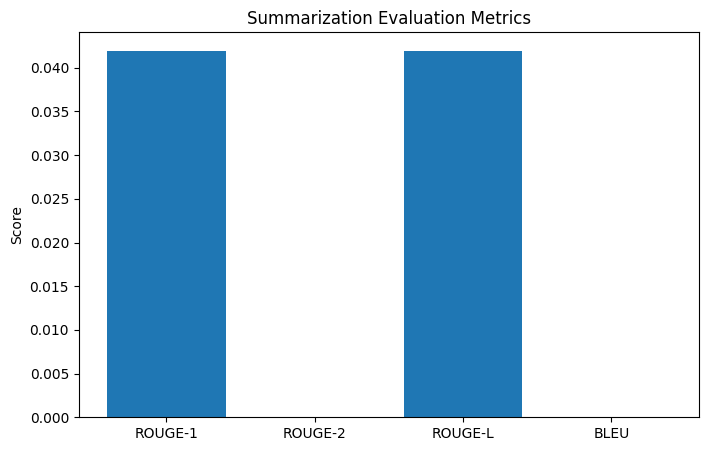

In [72]:
import matplotlib.pyplot as plt

# metric values
metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]
metric_values = [
    rouge_results["rouge1"],
    rouge_results["rouge2"],
    rouge_results["rougeL"],
    bleu_results["bleu"]
]

# create chart
plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)

plt.title("Summarization Evaluation Metrics")
plt.ylabel("Score")

plt.show()

##Evaluation Insights

- ROUGE scores are relatively low, indicating weak similarity between the generated and reference articles.
- BLEU score reached 0.0, showing that the generated text differs significantly from the expected output.
- Manual inspection confirmed that the fine-tuned model often copied noisy complaint text instead of generating structured recommendations.
- The small fine-tuning dataset (only a few examples) limited the model’s ability to generalize.
- In this project, n-shot prompting produced more reliable results than fine-tuning with a very small dataset.

## N-Shot Prompting Evaluation

- The Qwen 1.5B model using 2-shot prompting is evaluated with ROUGE and BLEU metrics to measure how closely the generated recommendation article matches the reference article.

- This evaluation helps compare prompt-engineering performance against the fine-tuned FLAN-T5 model.



Qwen 2-shot ROUGE: {'rouge1': np.float64(0.014814814814814815), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.014814814814814815), 'rougeLsum': np.float64(0.014814814814814815)}
Qwen 2-shot BLEU: {'bleu': 0.0, 'precisions': [0.125, 0.0, 0.0, 0.0], 'brevity_penalty': 6.023573837886479e-08, 'length_ratio': 0.05673758865248227, 'translation_length': 8, 'reference_length': 141}


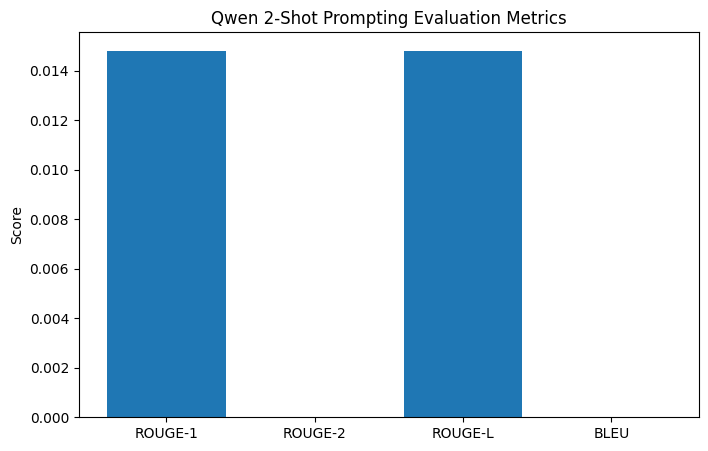

In [95]:
# evaluate Qwen 2-shot output manually stored as prediction
qwen_prediction = """PASTE YOUR 2-SHOT GENERATED ARTICLE HERE"""

# use the same reference article
reference_text = fine_tune_df["target_text"].iloc[0]

qwen_rouge_results = rouge.compute(
    predictions=[qwen_prediction],
    references=[reference_text]
)

qwen_bleu_results = bleu.compute(
    predictions=[qwen_prediction],
    references=[[reference_text]]
)

print("Qwen 2-shot ROUGE:", qwen_rouge_results)
print("Qwen 2-shot BLEU:", qwen_bleu_results)

import matplotlib.pyplot as plt

# metric values
metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]

metric_values = [
    qwen_rouge_results["rouge1"],
    qwen_rouge_results["rouge2"],
    qwen_rouge_results["rougeL"],
    qwen_bleu_results["bleu"]
]

# create chart
plt.figure(figsize=(8, 5))

plt.bar(metric_names, metric_values)

plt.title("Qwen 2-Shot Prompting Evaluation Metrics")

plt.ylabel("Score")

plt.show()

## Failure Cases and Iteration Tracking

### Initial Generator Output
- The first generator outputs contained hallucinations and reused example product names.
- Some responses included products or features not present in the input data.

### Prompt Engineering Improvements
- Adding stricter prompt rules improved factual consistency.
- N-shot prompting improved article structure and recommendation quality.
- Simpler examples reduced unwanted copying behavior.

### Fine-Tuning Experiment
- Fine-tuning FLAN-T5 Small on a very small dataset produced weak results.
- The model often copied noisy complaint text directly from the input.
- Evaluation metrics (ROUGE/BLEU) confirmed weak generation quality.

### Best Performing Approach
- Qwen 1.5B with n-shot prompting produced the most reliable and readable recommendation articles.
- Prompt engineering proved more effective than small-scale fine-tuning in this project.

### Lessons Learned
- Generative AI models require high-quality training examples and careful prompt design.
- Small datasets are often insufficient for reliable fine-tuning.
- Manual inspection is important because automatic metrics alone cannot fully capture output quality.

##Final Conclusions

- The project successfully demonstrates an end-to-end NLP pipeline for analyzing customer reviews.

- The sentiment classifier (DistilBERT) achieved strong performance (~95% accuracy), although dataset imbalance affected the detection of neutral reviews.

- The clustering approach (MiniLM embeddings + KMeans) revealed meaningful product groupings. While the silhouette score was relatively low, manual inspection confirmed useful thematic clusters.

- The summarization pipeline explored multiple generation approaches, including zero-shot prompting, n-shot prompting, and fine-tuning.

- Qwen 1.5B combined with n-shot prompting produced the most reliable and structured recommendation articles.

- Fine-tuning FLAN-T5 Small on a very small dataset resulted in weak generation quality, demonstrating that generative models require larger and higher-quality datasets for effective fine-tuning.

- ROUGE and BLEU evaluation metrics confirmed the limitations of the fine-tuned model, while manual inspection highlighted issues such as hallucinations and noisy text copying.

- Prompt engineering proved to be highly important for improving factual consistency and output structure in generative AI systems.

- Overall, combining classification, clustering, and generation transformed raw customer reviews into meaningful business insights and recommendation summaries.

- Limitations of the project include dataset imbalance, noisy review text, limited fine-tuning data, and the inherent challenges of unsupervised clustering and generative AI reliability.

# AI-Generated Product Recommendation Articles

These recommendation articles were generated using NLP techniques including sentiment classification, clustering, prompt engineering, and generative AI models.
(Note: clusters overlap semantically)
---

# Cluster 0 — Tablets / Multimedia Devices

## Top Products
- All-New Fire HD 8 Tablet (Black)
- All-New Fire HD 8 Tablet (Magenta)
- Fire Tablet 7 Display (Black)

## Generated Recommendation Article

The All-New Fire HD 8 Tablet stands out as a top performer, boasting an 8 HD Display with Wi-Fi connectivity and ample storage. Customers praise its high-quality screen, but some express frustration with the headphone jack restarting upon plugging headphones in, leading to just two-star ratings overall.

However, there's a stark contrast with the All-New Fire HD 8 Tablet (Magenta), which has slightly lower reviews due to battery issues and poor connectivity, though still receiving four-and-a-half stars. For those prioritizing connectivity and compatibility, the Fire Tablet 7 Display with Wi-Fi is recommended, offering excellent performance despite having fewer stars.

The All-New Fire HD 8 Tablet (Blue) receives the lowest rating, indicating significant dissatisfaction among customers who find it super slow and lacks adequate memory.

---

# Cluster 1 — Kindle / Reading Devices

## Top Products
- Fire Tablet with Alexa 7 Display 16 GB Blue
- Amazon Kindle Paperwhite
- Fire Kids Edition Tablet 7 Display Green Kid-Proof Case

## Generated Recommendation Article

The Fire Tablet with Alexa stands out as a versatile device suitable for reading, media consumption, and everyday use. The Amazon Kindle Paperwhite is highly rated for its e-reader functionality and portability. The Fire Kids Edition Tablet also received positive ratings from several users.

Common complaints include difficult navigation, unwanted game popups, weaker speaker quality, and issues with SD card stability and factory resets.

The All-New Fire HD 8 Tablet (Magenta) received the weakest feedback in this group. Some users reported performance and usability frustrations.

For users focused on reading and general tablet usage, the Fire Tablet with Alexa and the Kindle Paperwhite are the strongest options in this cluster.

---

# Cluster 2 — Batteries / General Products

## Top Products
- AmazonBasics AA Performance Alkaline Batteries (48 Count)
- AmazonBasics AAA Performance Alkaline Batteries (36 Count)

## Generated Recommendation Article

The AmazonBasics AA Performance Alkaline Batteries (48 Count) offer reliable performance for everyday devices and received stronger customer ratings overall.

The AmazonBasics AAA Performance Alkaline Batteries (36 Count) were also commonly used but received significantly more negative feedback from customers.

Common complaints included short battery life, inconsistent performance, and weak durability across devices such as remotes, cameras, and TV accessories.

Several users reported batteries failing shortly after installation or draining unusually fast.

Based on customer feedback, the AA battery version is the more reliable option, while the AAA version received the weakest overall reviews in this cluster.

---

# Cluster 3 — Smart Home / Alexa Devices

## Top Products
- Amazon Kindle Paperwhite
- Amazon Echo Plus with Built-In Hub
- All-New Fire HD 8 Tablet (Black)

## Generated Recommendation Article

The Amazon Kindle Paperwhite received excellent customer feedback thanks to its strong reading experience and touchscreen functionality. The Amazon Echo Plus also performed very well, especially for users interested in smart home integration and voice assistant features.

The All-New Fire HD 8 Tablet (Black) received positive reviews for its display quality and multimedia capabilities.

However, several complaints mentioned poor quality control, fast battery drain, weak voice recognition, and accessory compatibility issues.

The Brand New Amazon Kindle Fire 16GB Tablet received the weakest feedback in this cluster due to performance concerns and poor user experience.

Overall, the Amazon Echo Plus and Kindle Paperwhite are the strongest recommendations in this category.

---

# Cluster 4 — Gifts / Casual Usage

## Top Products
- All-New Fire HD 8 Tablet (Black)
- All-New Fire HD 8 Tablet with Alexa (Marine Blue)
- Fire Tablet 7 Display (Black)

## Generated Recommendation Article

The All-New Fire HD 8 Tablet received strong customer feedback for its display quality, Wi-Fi performance, and overall usability. The version with Alexa integration was also positively reviewed for its additional smart assistant functionality.

The Fire Tablet 7 Display performed well as a casual-use tablet suitable for entertainment and simple everyday tasks.

Some customer complaints focused on poor child usability, misleading advertising, and products not being as kid-friendly as expected.

The Fire Tablet with Alexa (Magenta) received the weakest feedback in this cluster, with several users reporting frustration regarding usability and overall product experience.

For casual usage and multimedia consumption, the All-New Fire HD 8 Tablet models are the strongest recommendations in this group.